In [1]:
import numpy as np

from olbootstrap.experiments._experiments import OnlineARBootstrapExperiment
from olbootstrap.plotting._plotting import BootstrapPlotter
from olbootstrap.synthetic_time_series._ar1 import AR1Process
from olbootstrap.synthetic_time_series._garch import GARCH11Process

/opt/anaconda3/envs/bootstrap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Uniform covered: True | fraction covered: 1.000 | last q_active≈4.572547995626645


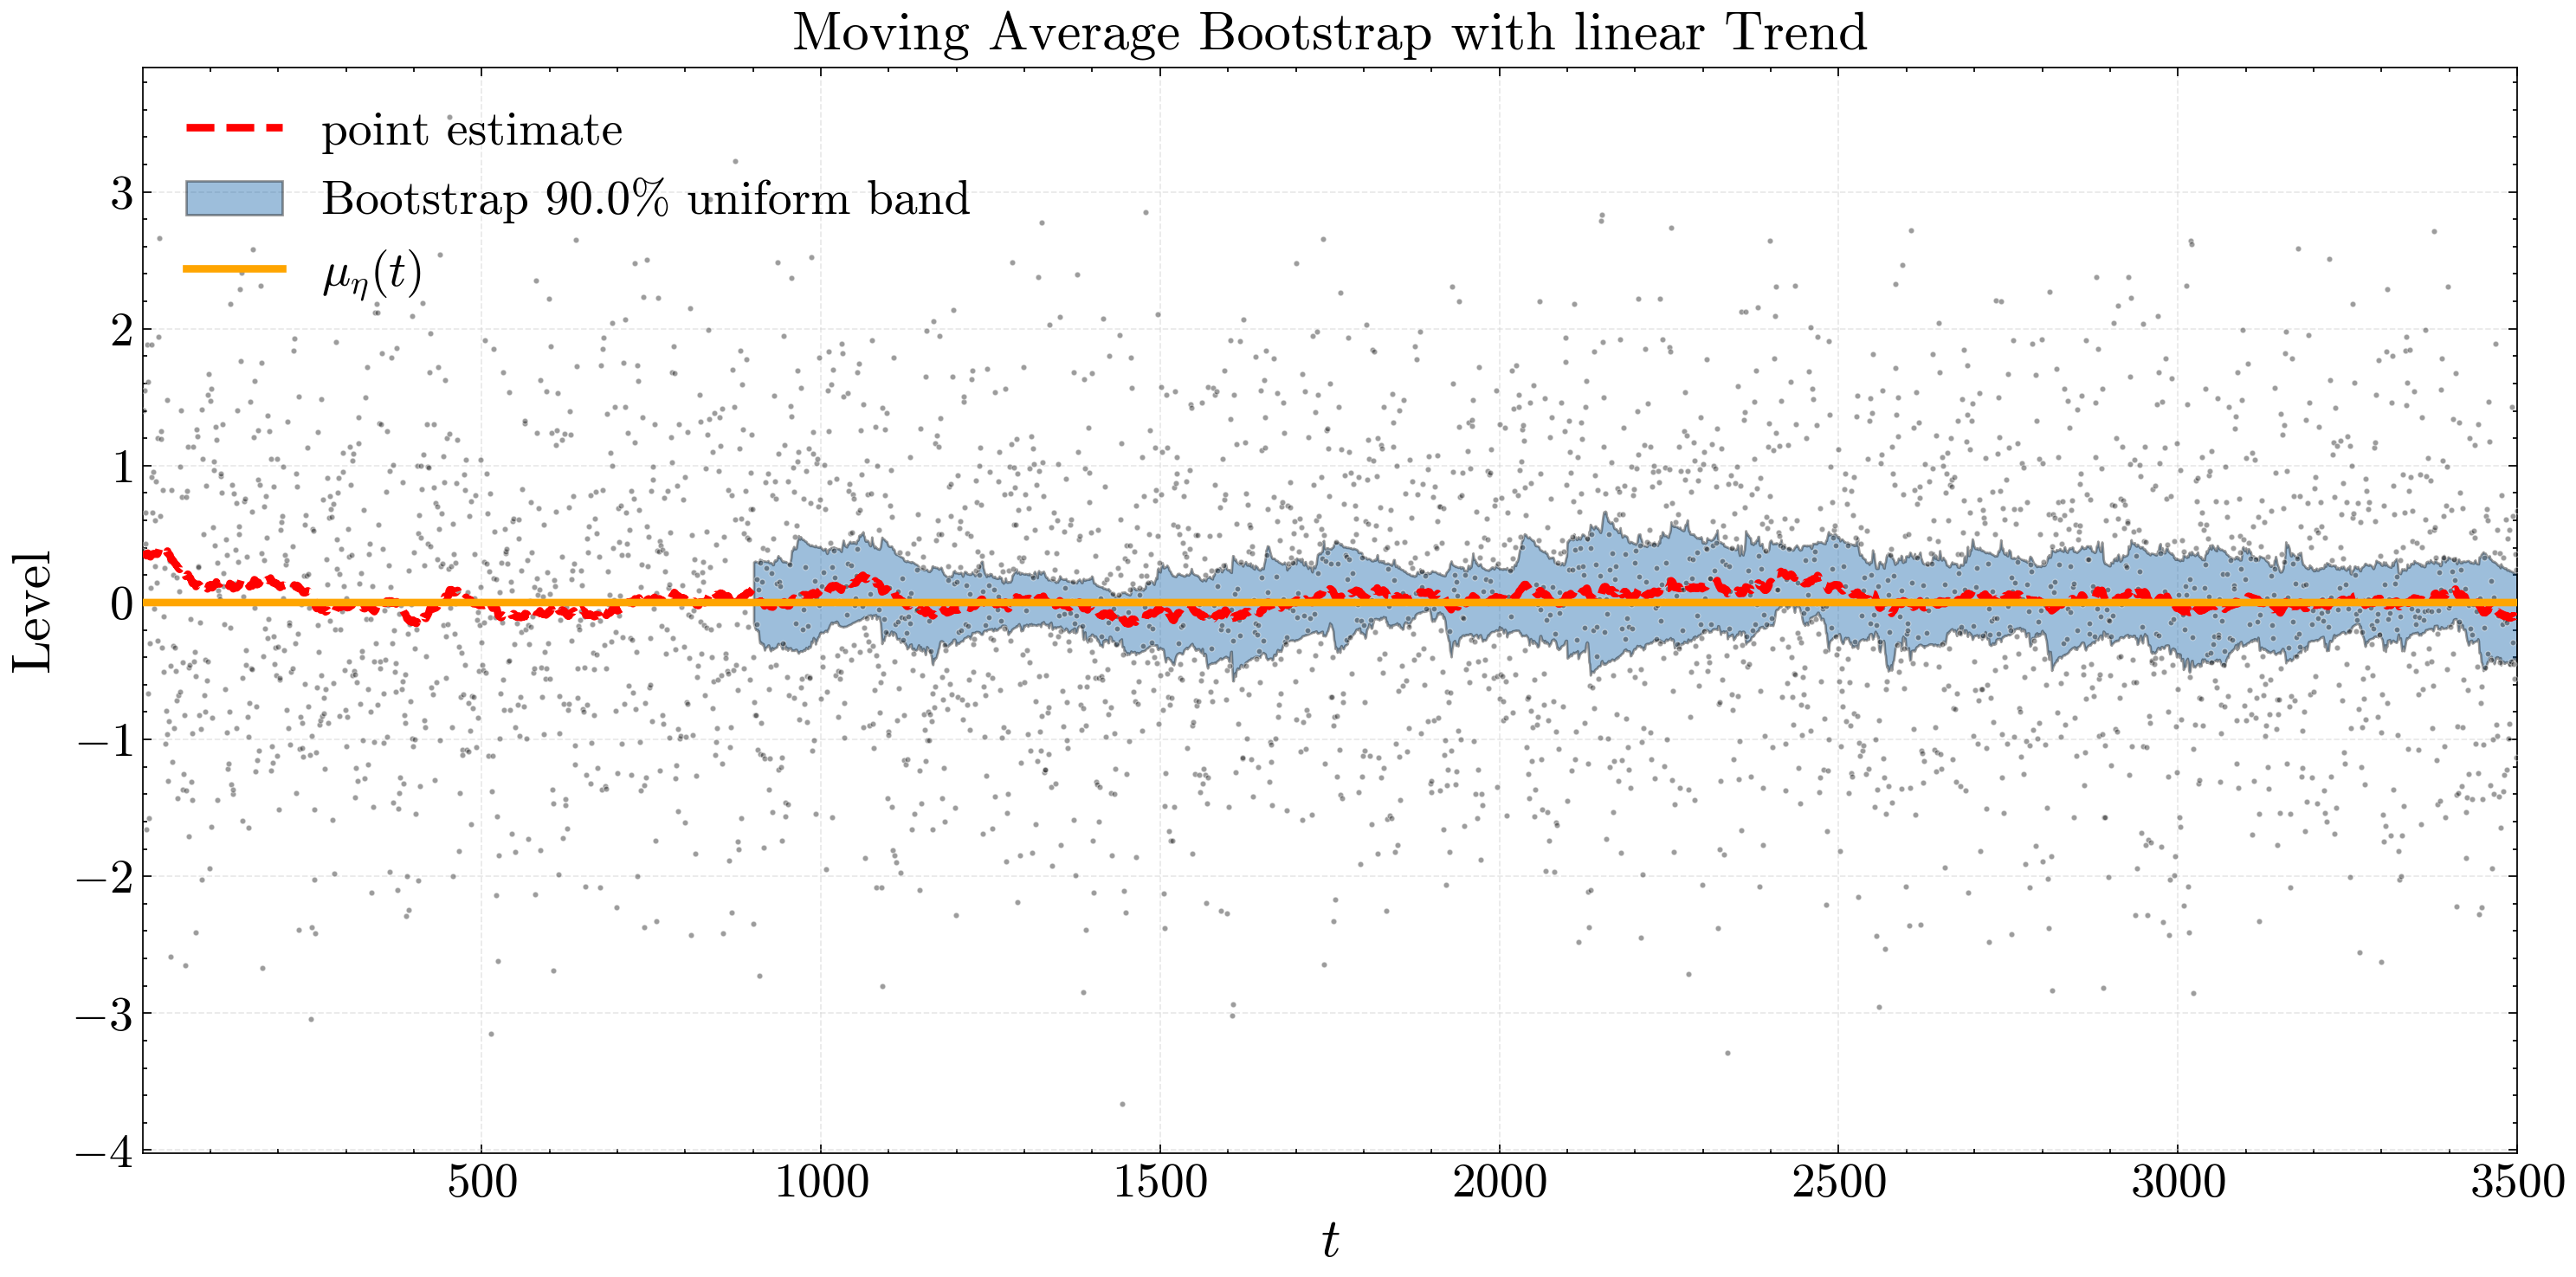

In [2]:
master = np.random.SeedSequence(12323)
rng_data, rng_weights = [np.random.default_rng(ss) for ss in master.spawn(2)]

mean = 0
sample_size = 3500

ar_proc = AR1Process(
    mean=mean,
    phi=0.2,
    noise_std=1,
    trend_slope=0.0,
    rng=rng_data,
)

samples = ar_proc.generate_samples(sample_size)

exp_ar_trend = OnlineARBootstrapExperiment(
    sample_size=sample_size,
    process=ar_proc,
    B=100,
    record_every=1,
    smoothing_method="ewma",
    eta=2 / 250,
    burn_in=500,
    var_warmup=400,
    smoothing_beta=None,
    gamma=None,
    seasonal_period=None,
    forecast_s=0,
    progress=True,
    old_bootstrap=False,
    rng_weights=rng_weights,
    transform="student",
    transform_power=1.0 / 3.0,
    use_variance_smoothing=False,
    alpha=0.1,
)

exp_ar_trend.run(samples=samples)
exp_ar_trend.compute_intervals(quantile="normal")
u_lo, u_up, q_last = exp_ar_trend.compute_uniform_bands()
cov_both = exp_ar_trend.compute_coverage(band="both")

if "uniform_covered" in cov_both:
    u_bool = bool(cov_both["uniform_covered"])
    u_mask = cov_both.get("uniform_mask", None)
    u_frac = (
        float(np.mean(u_mask))
        if (u_mask is not None and u_mask.size > 0)
        else float("nan")
    )
    print(
        f"Uniform covered: {u_bool} | fraction covered: {u_frac:.3f} | last q_active≈{q_last}"
    )

res = exp_ar_trend.results()
plotter = BootstrapPlotter(style="science")
fig, ax, _ = plotter.plot_bootstrap(
    res,
    plot_series=True,
    alpha=0.1,
    title=f"Moving Average Bootstrap with linear Trend",
    dpi=250,
    show_mu=False,
    show_pointwise_band=False,
    marker_size=1.5,
)

Uniform covered: True | fraction covered: 1.000 | last q_active≈4.19424065063148


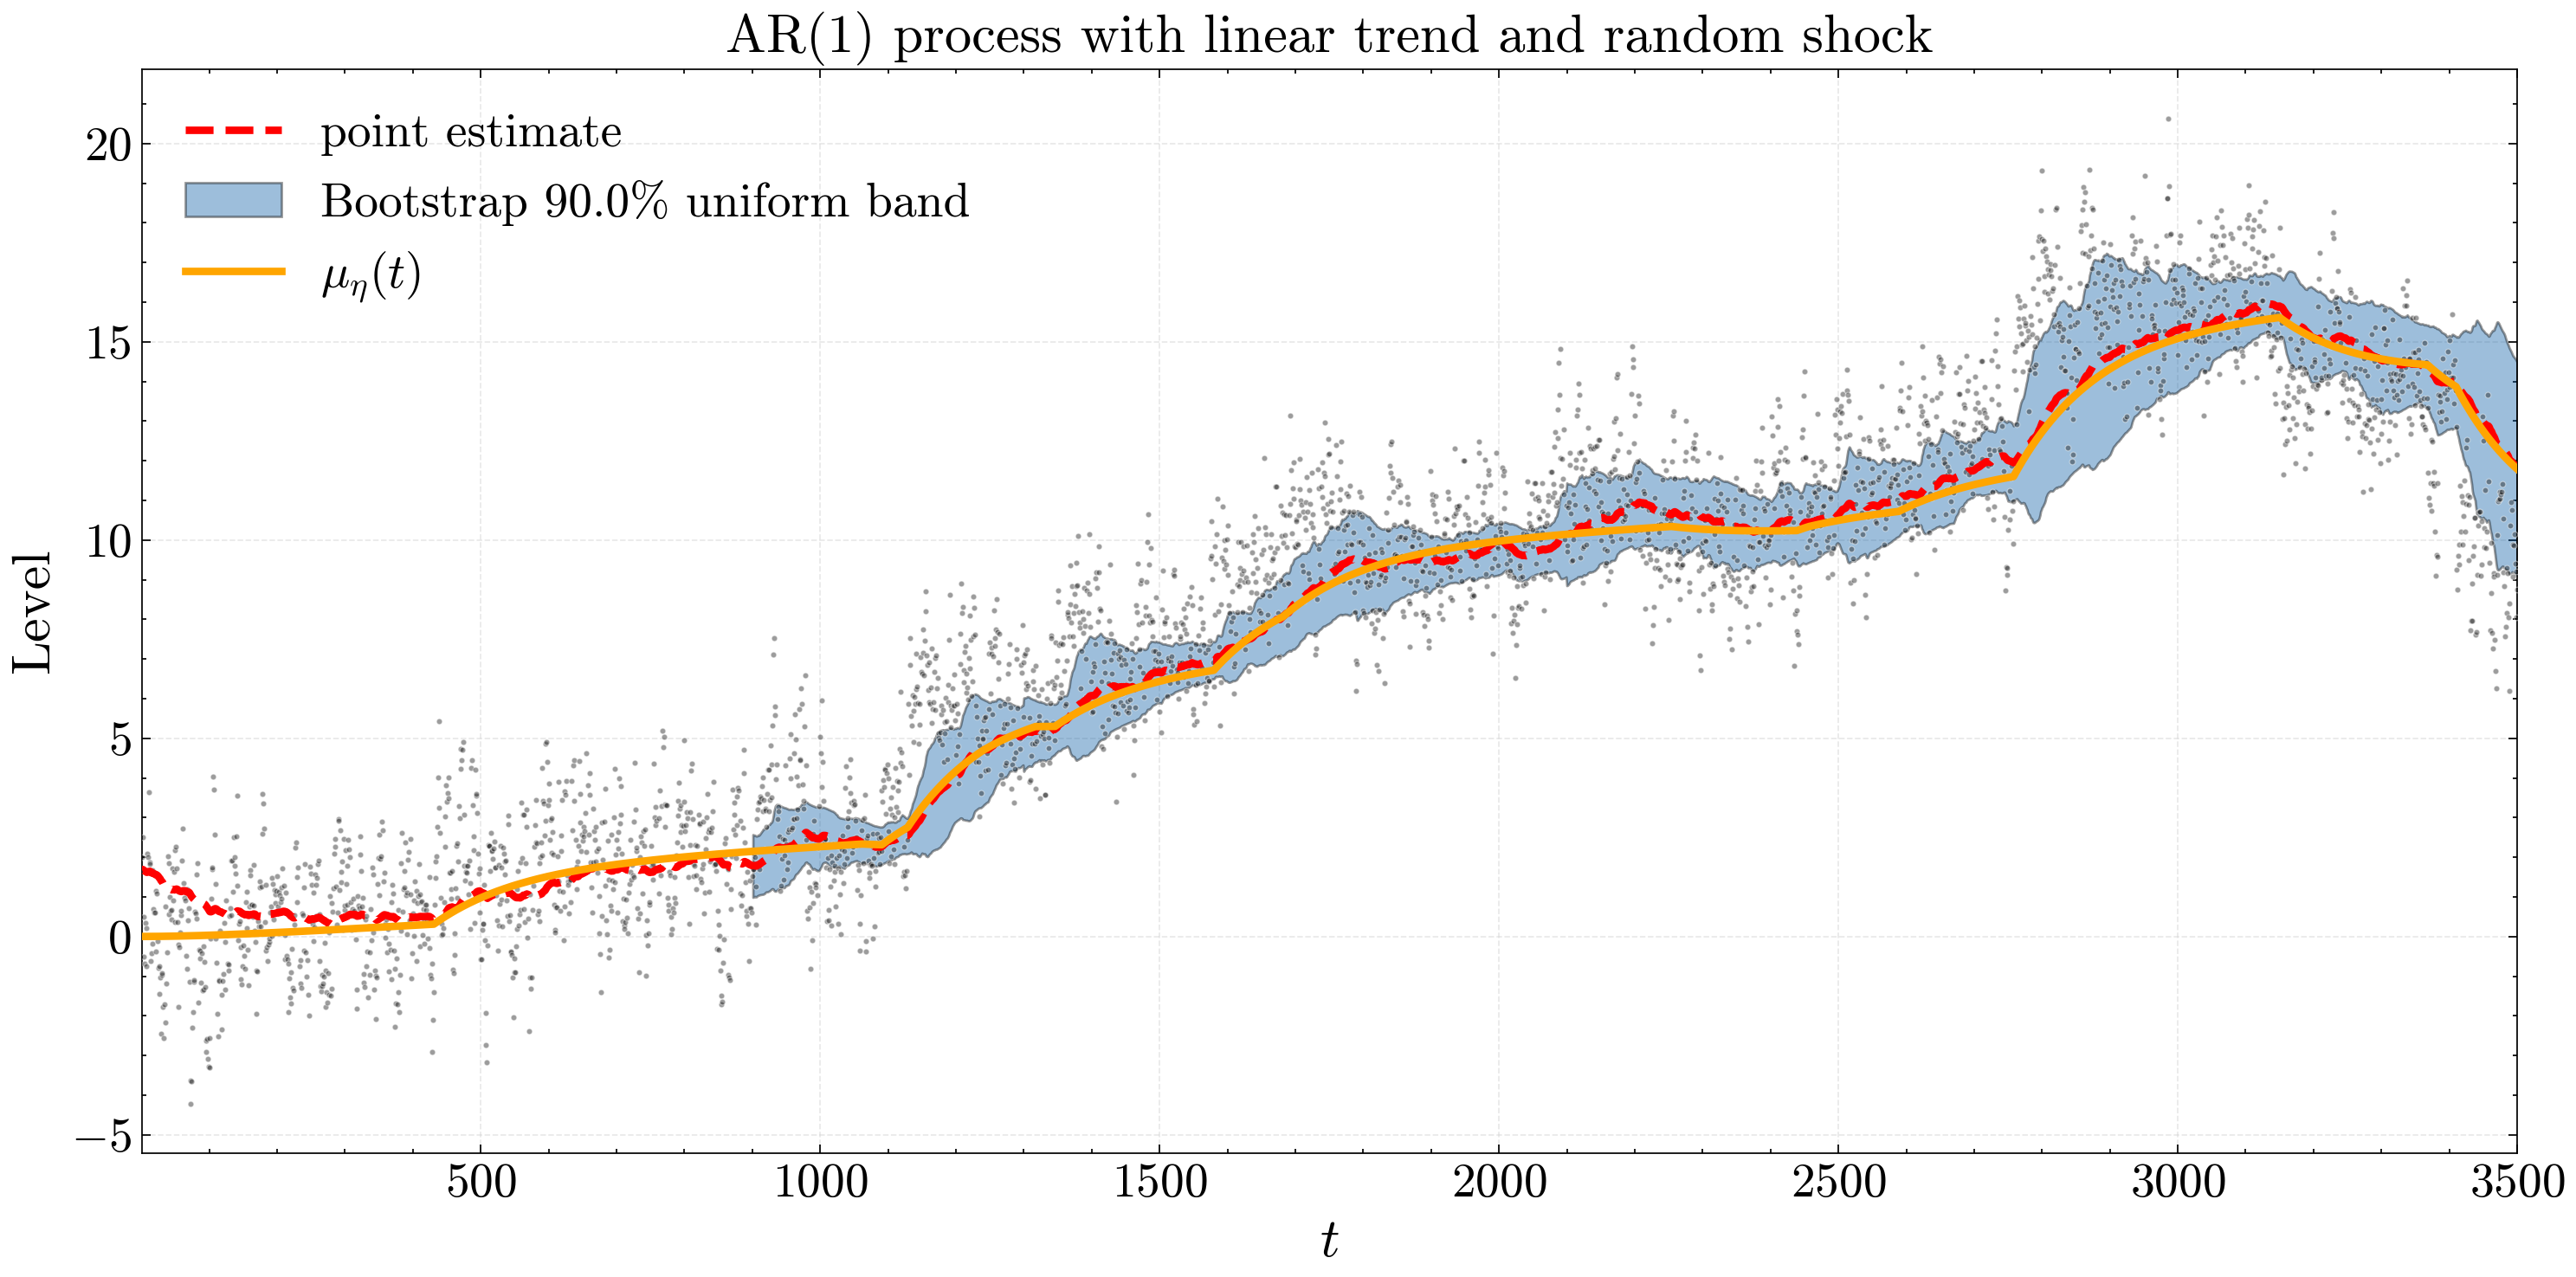

In [3]:
from numpy.random import SeedSequence, default_rng

master = SeedSequence(123235)
rng_data, rng_weights = [default_rng(ss) for ss in master.spawn(2)]

mean = 0.0
sample_size = 3500
B = 100
burn_in = 500
var_warmup = 400

shock_proc = AR1Process(
    mean=mean,
    phi=0.7,
    noise_std=1,
    trend_slope=0.001,
    rng=rng_data,
    shock_type="permanent",
    jump_prob=0.005,
    jump_scale=2,
)

samples = shock_proc.generate_samples(sample_size)
exp_ar = OnlineARBootstrapExperiment(
    sample_size=sample_size,
    process=shock_proc,
    B=B,
    record_every=1,
    smoothing_method="ewma",
    eta=2 / 250,
    burn_in=burn_in,
    var_warmup=var_warmup,
    smoothing_beta=None,
    gamma=None,
    seasonal_period=None,
    forecast_s=0,
    progress=True,
    old_bootstrap=False,
    rng_weights=rng_weights,
    transform="student",
    transform_power=1.0 / 3.0,
    use_variance_smoothing=False,
    alpha=0.1,
)

exp_ar.run(samples=samples)
exp_ar.compute_intervals(quantile="normal")
u_lo, u_up, q_last = exp_ar.compute_uniform_bands()
cov_both = exp_ar.compute_coverage(band="both")

if "uniform_covered" in cov_both:
    u_bool = bool(cov_both["uniform_covered"])
    u_mask = cov_both.get("uniform_mask", None)
    u_frac = (
        float(np.mean(u_mask))
        if (u_mask is not None and u_mask.size > 0)
        else float("nan")
    )
    print(
        f"Uniform covered: {u_bool} | fraction covered: {u_frac:.3f} | last q_active≈{q_last}"
    )


res = exp_ar.results()
plotter = BootstrapPlotter(style="science")
fig, ax, _ = plotter.plot_bootstrap(
    res,
    plot_series=True,
    alpha=0.1,
    title="AR(1) process with linear trend and random shock",
    dpi=250,
    show_mu=False,
    show_pointwise_band=False,
    marker_size=1.5,
)

Uniform covered: True | fraction covered: 1.000 | last q_active≈3.933908859294257


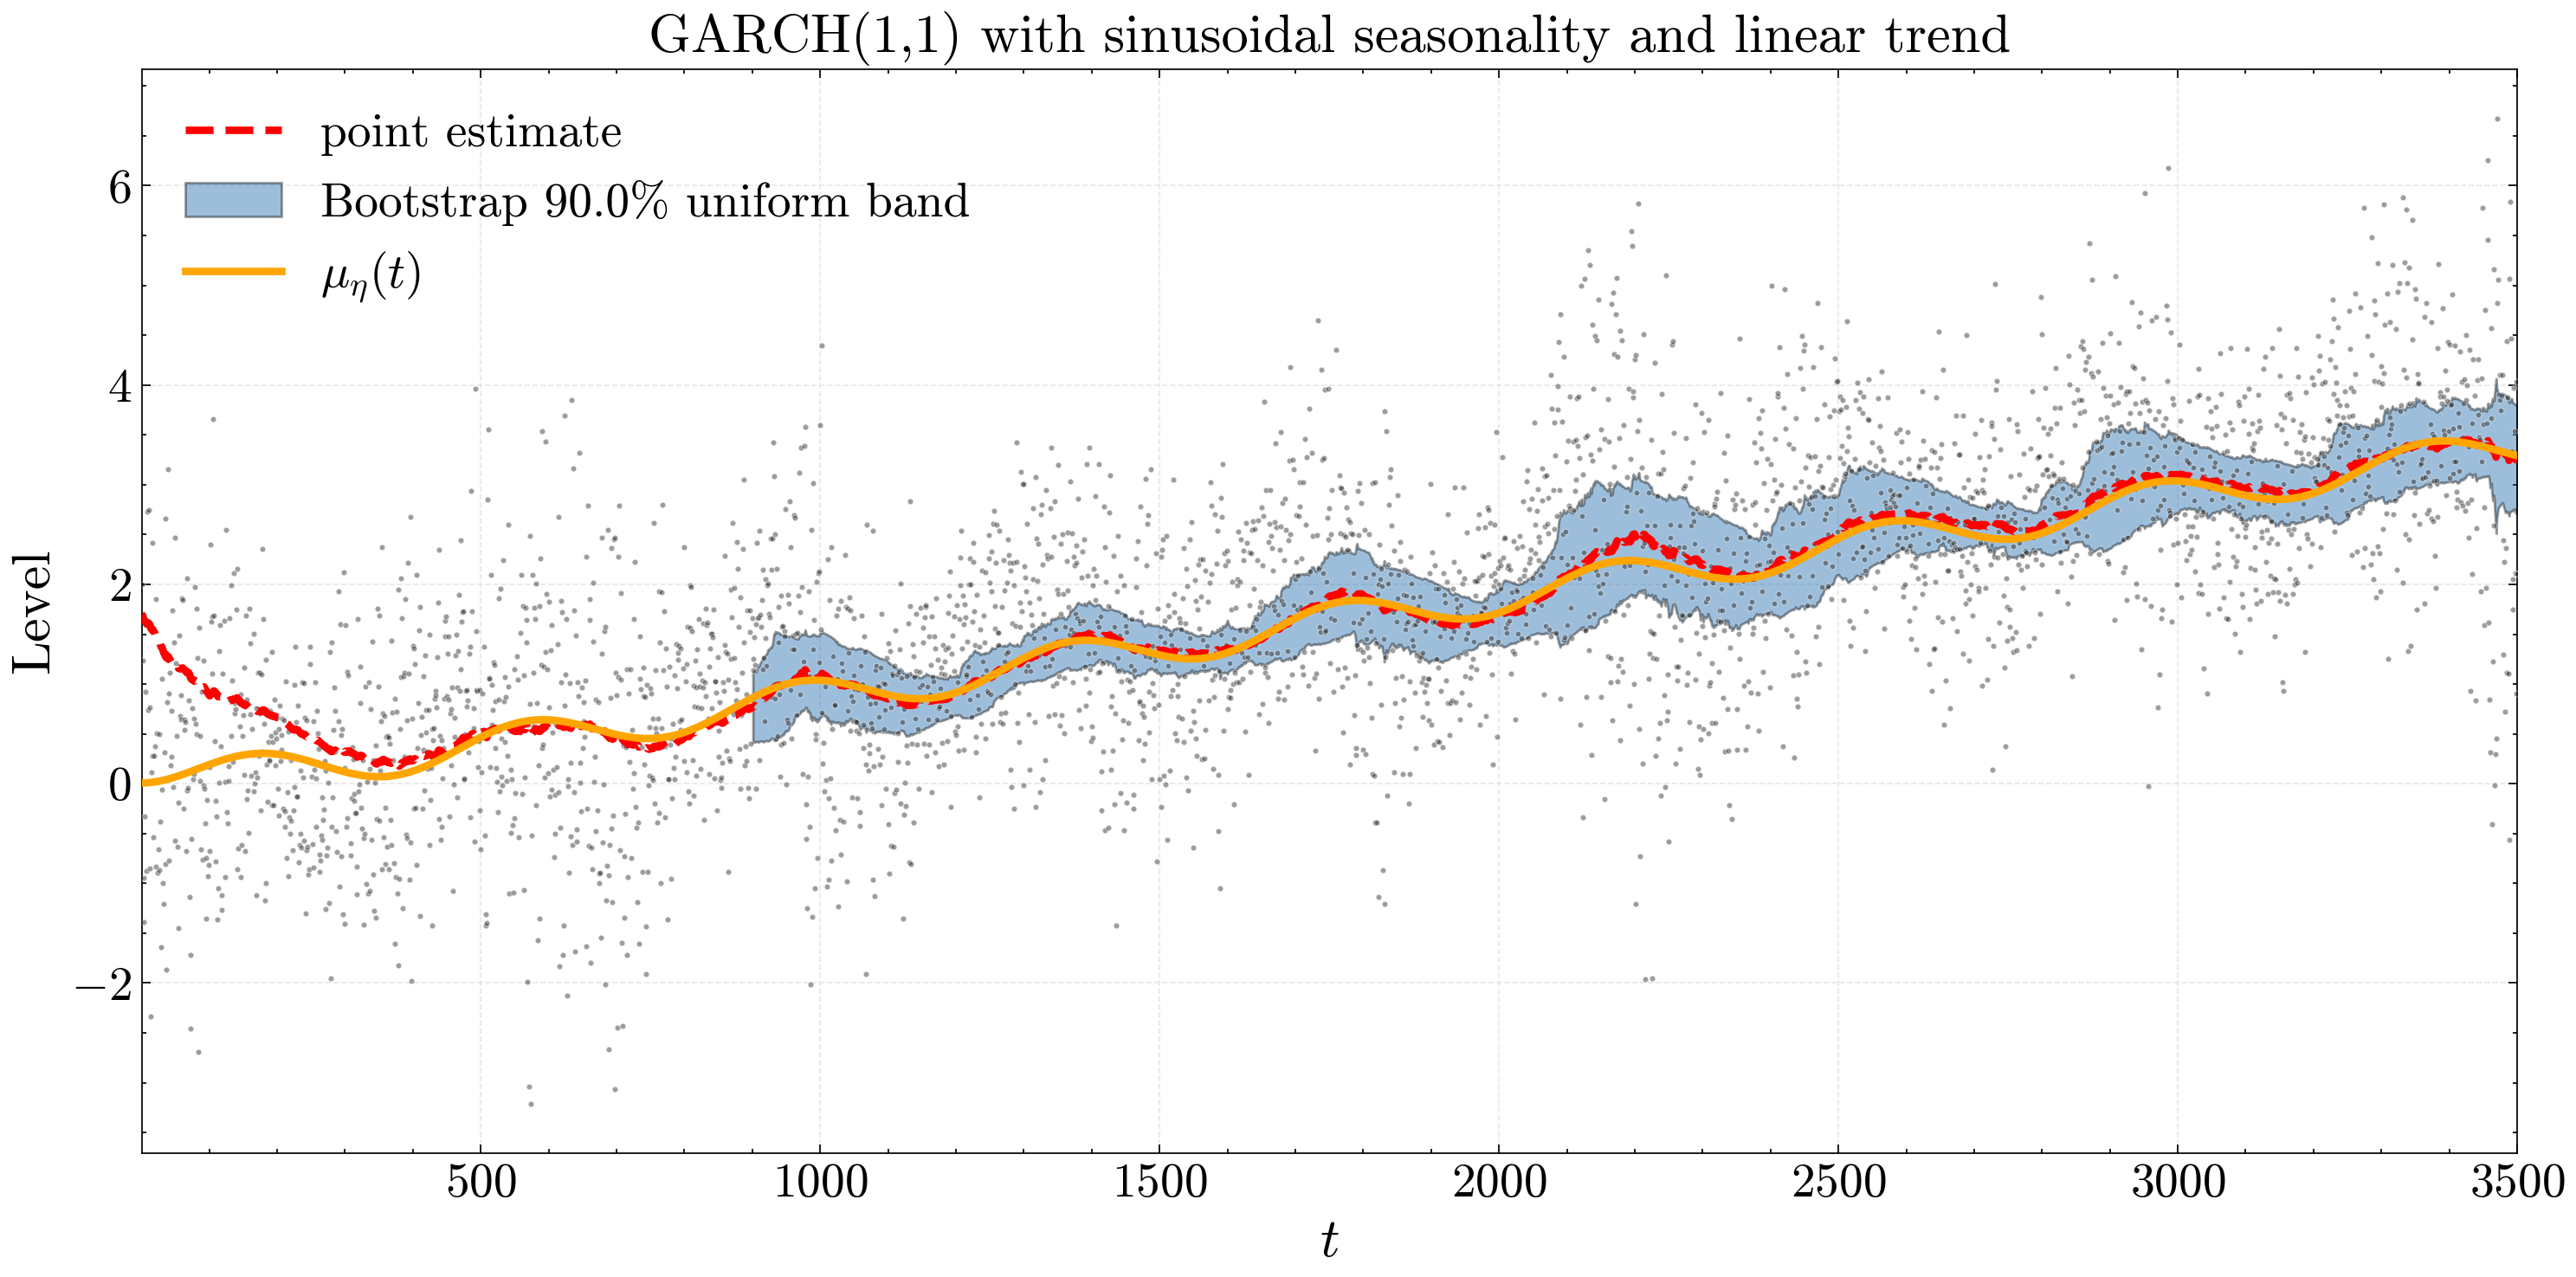

In [4]:
master = SeedSequence(123235)
rng_data, rng_weights = [default_rng(ss) for ss in master.spawn(2)]

mean = 0.0
sample_size = 3500
B = 100
burn_in = 500
var_warmup = 400

persistence = 0.98
alpha_garch = 0.08
beta_garch = persistence - alpha_garch
target_var = 1.0
omega_garch = (1 - persistence) * target_var

garch_proc = GARCH11Process(
    mean=mean,
    omega=omega_garch,
    alpha=alpha_garch,
    beta=beta_garch,
    trend_slope=0.001,
    seasonal_amplitude=0.4,
    seasonal_period=400,
    seasonal_phase=0.0,
    noise_std=1.0,
    rng=rng_data,
)

samples = garch_proc.generate_samples(sample_size)

exp_garch = OnlineARBootstrapExperiment(
    sample_size=sample_size,
    process=garch_proc,
    B=B,
    record_every=1,
    smoothing_method="ewma",
    eta=2 / 250,
    burn_in=burn_in,
    var_warmup=var_warmup,
    smoothing_beta=None,
    gamma=None,
    seasonal_period=None,
    forecast_s=0,
    progress=True,
    old_bootstrap=False,
    rng_weights=rng_weights,
    transform="student",
    use_variance_smoothing=False,
    transform_power=1.0 / 3.0,
    alpha=0.1,
)

exp_garch.run(samples=samples)

exp_garch.compute_intervals(quantile="normal")
u_lo, u_up, q_last = exp_garch.compute_uniform_bands()
cov_both = exp_garch.compute_coverage(band="both")

if "uniform_covered" in cov_both:
    u_bool = bool(cov_both["uniform_covered"])
    u_mask = cov_both.get("uniform_mask", None)
    u_frac = (
        float(np.mean(u_mask))
        if (u_mask is not None and u_mask.size > 0)
        else float("nan")
    )
    print(
        f"Uniform covered: {u_bool} | fraction covered: {u_frac:.3f} | last q_active≈{q_last}"
    )

res = exp_garch.results()
plotter = BootstrapPlotter(style="science")
fig, ax, _ = plotter.plot_bootstrap(
    res,
    plot_series=True,
    alpha=0.1,
    title="GARCH(1,1) with sinusoidal seasonality and linear trend",
    dpi=250,
    marker_size=1.5,
    show_mu=False,
    show_pointwise_band=False,
)

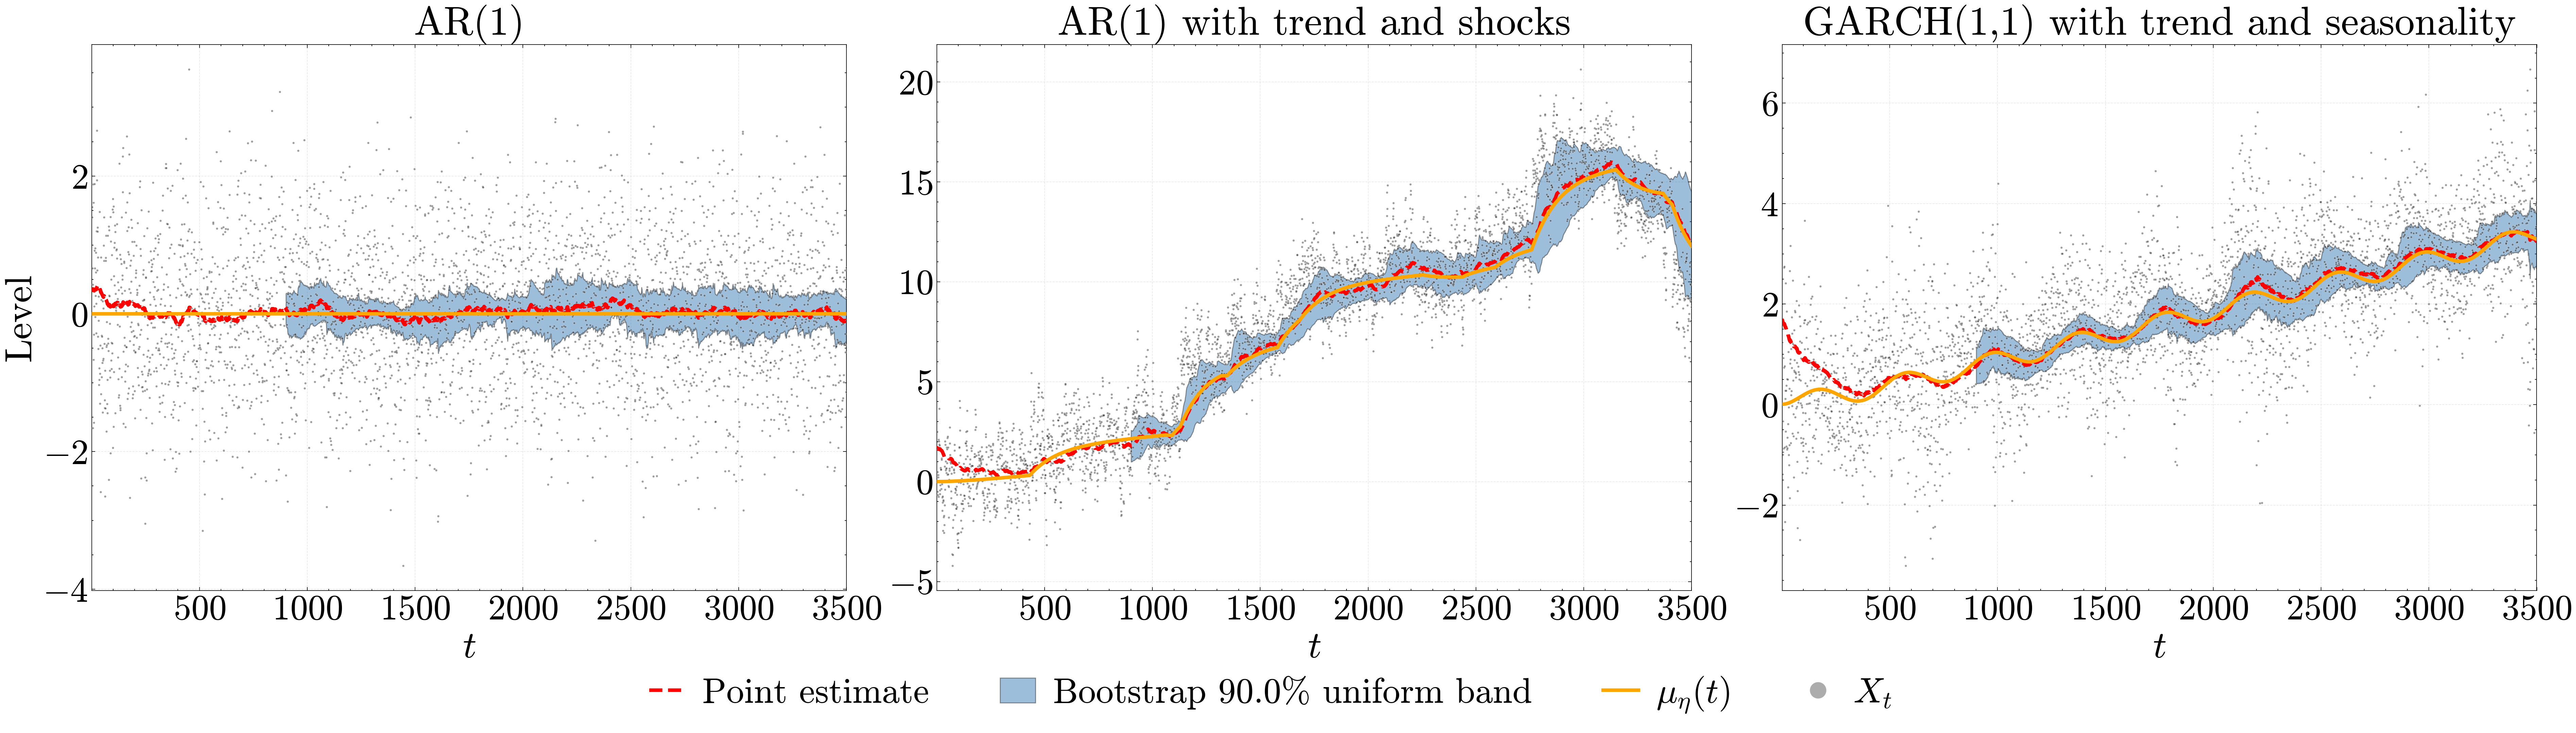

In [5]:
res_ma = exp_ar_trend.results()
res_ar = exp_ar.results()
res_garch = exp_garch.results()

plotter = BootstrapPlotter(style="science", figsize=(12, 10), dpi=250)

fig, axes, _ = plotter.plot_bootstrap_grid(
    [res_ma, res_ar, res_garch],
    titles=[
        f"AR(1)",
        "AR(1) with trend and shocks",
        "GARCH(1,1) with trend and seasonality",
    ],
    layout=(1, 3),
    common_legend=True,
    align_axes=False,
    legend_loc="lower center",
    legend_ncol=None,
    legend_bbox=(0.5, -0.06),
    reduce_whitespace=True,
    hspace=0.25,
    wspace=0.12,
    bottom_pad=0.16,
    legend_fontsize=30,
    tick_labelsize=30,
    axis_labelsize=32,
    title_size=34,
    marker_size=1,
    line_width=3,
    plot_series=True,
    show_mu=False,
    show_pointwise_band=False,
    alpha=0.1,
    ylabel="Level",
    save_path="figs/compare_ar_garch.pdf",
)